In [1]:
import sys, os
if os.path.basename(os.getcwd()) == 'notebooks':
    sys.path.insert(0, '..')

# 01 — Data Exploration
Load all three EEG datasets and inspect shape, class balance, and feature statistics.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.data_loader import get_all_datasets

datasets = get_all_datasets()

2026-05-15 18:39:44,965 — Downloading UCI Epileptic Seizure Recognition dataset...
2026-05-15 18:39:46,634 — Failed to download UCI Seizure dataset: HTTP Error 404: Not Found. Returning synthetic data.
2026-05-15 18:39:46,721 — Bonn dataset files not found. Using synthetic fallback (500, 4097).
2026-05-15 18:39:46,722 — Generating synthetic Bonn-like data for development...


In [3]:
# Shape and class distribution
summary = []
for name, (X, y) in datasets.items():
    unique, counts = np.unique(y, return_counts=True)
    ratio = counts[1] / counts[0] if len(counts) > 1 else float('nan')
    summary.append({
        'Dataset': name,
        'Samples': X.shape[0],
        'Features': X.shape[1],
        'Class 0': counts[0],
        'Class 1': counts[1] if len(counts) > 1 else 0,
        'Imbalance Ratio (1:0)': f'{ratio:.2f}',
    })
    print(f'=== {name} ===')
    print(f'  Shape: {X.shape}')
    print(f'  Class distribution: {dict(zip(unique.tolist(), counts.tolist()))}')
    print(f'  Feature range: [{X.min():.3f}, {X.max():.3f}]')
    print()

pd.DataFrame(summary)

=== uci_seizure ===
  Shape: (11500, 178)
  Class distribution: {0: 5699, 1: 5801}
  Feature range: [-4.829, 4.828]

=== bonn_eeg ===
  Shape: (500, 4097)
  Class distribution: {0: 300, 1: 200}
  Feature range: [-4.829, 4.828]

=== eeg_eye_state ===
  Shape: (14980, 14)
  Class distribution: {0: 8257, 1: 6723}
  Feature range: [86.667, 715897.000]



,Dataset,Samples,Features,Class 0,Class 1,Imbalance Ratio (1:0)
0,uci_seizure,11500,178,5699,5801,1.02
1,bonn_eeg,500,4097,300,200,0.67
2,eeg_eye_state,14980,14,8257,6723,0.81


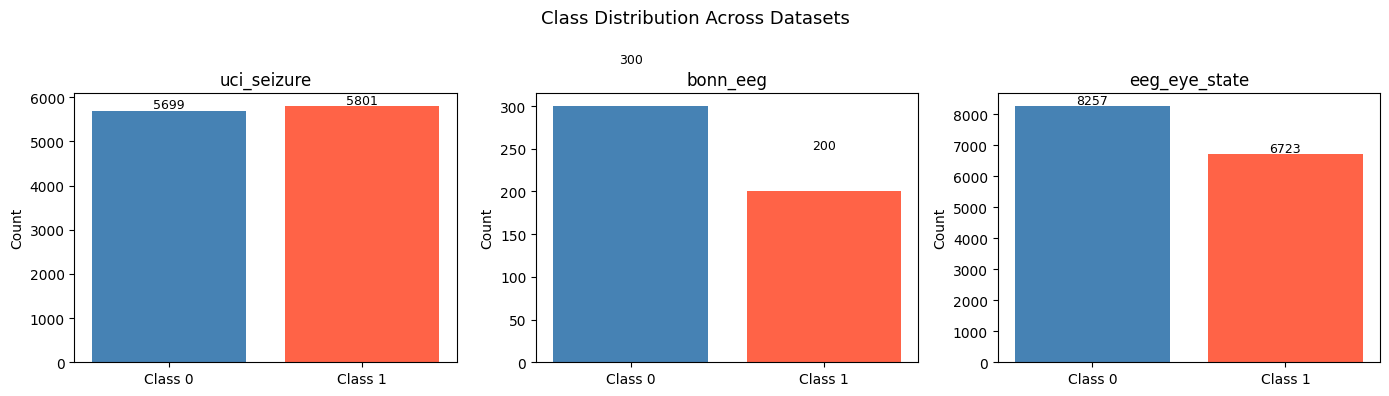

In [4]:
# Class balance bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, (X, y)) in zip(axes, datasets.items()):
    unique, counts = np.unique(y, return_counts=True)
    ax.bar(['Class 0', 'Class 1'], counts, color=['steelblue', 'tomato'])
    ax.set_title(name)
    ax.set_ylabel('Count')
    for i, c in enumerate(counts):
        ax.text(i, c + 50, str(c), ha='center', fontsize=9)
plt.suptitle('Class Distribution Across Datasets', fontsize=13)
plt.tight_layout()
plt.savefig('../results/figures/class_distribution.png', dpi=150)
plt.show()

In [5]:
# Feature statistics per dataset
for name, (X, y) in datasets.items():
    df = pd.DataFrame(X)
    print(f'=== {name} — Feature Statistics (first 5 features) ===')
    print(df.iloc[:, :5].describe().round(3))
    print()

=== uci_seizure — Feature Statistics (first 5 features) ===
               0          1          2          3          4
count  11500.000  11500.000  11500.000  11500.000  11500.000
mean       0.003     -0.002     -0.023     -0.014     -0.005
std        1.008      1.002      0.994      1.007      0.994
min       -3.745     -3.817     -4.211     -4.055     -3.639
25%       -0.672     -0.692     -0.691     -0.688     -0.677
50%        0.012      0.010     -0.016     -0.018      0.001
75%        0.673      0.671      0.642      0.659      0.666
max        4.059      4.479      3.837      4.828      4.006

=== bonn_eeg — Feature Statistics (first 5 features) ===
             0        1        2        3        4
count  500.000  500.000  500.000  500.000  500.000
mean     0.029   -0.036   -0.011   -0.031    0.010
std      0.995    1.003    1.040    0.993    0.983
min     -2.629   -3.568   -3.004   -2.738   -2.638
25%     -0.606   -0.665   -0.773   -0.712   -0.685
50%      0.015   -0.055   -

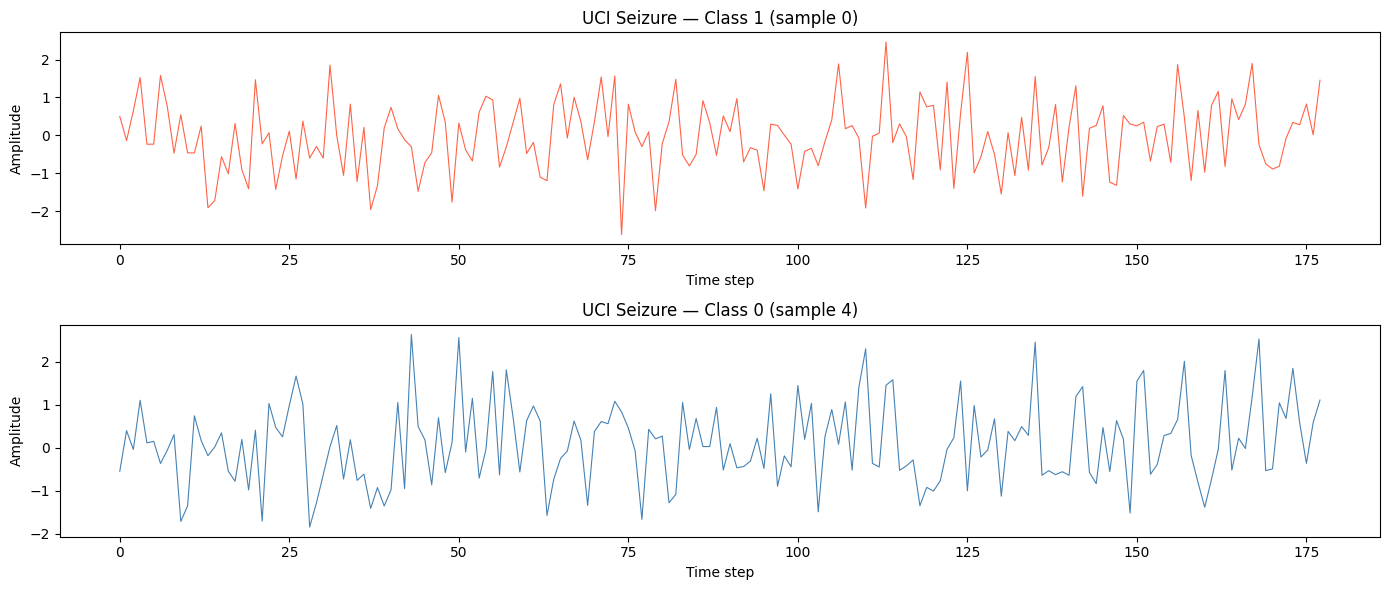

In [6]:
# Sample signal plot for UCI Seizure (first 5 samples)
X_uci, y_uci = datasets['uci_seizure']
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
for ax, label, color in zip(axes, [1, 0], ['tomato', 'steelblue']):
    idx = np.where(y_uci == label)[0][0]
    ax.plot(X_uci[idx], color=color, linewidth=0.8)
    ax.set_title(f'UCI Seizure — Class {label} (sample {idx})')
    ax.set_xlabel('Time step')
    ax.set_ylabel('Amplitude')
plt.tight_layout()
plt.savefig('../results/figures/sample_signals_uci.png', dpi=150)
plt.show()